# Detector de SPAM explicado

**Alumno:** Nestor Hugo Biedma

Este notebook acompaña la resolución del ejercicio del Módulo 6. La idea es entender el flujo completo: cargar datos, separar entrenamiento y evaluación, entrenar dos clasificadores y comparar sus errores.

## 1. Problema supervisado

Queremos predecir si un correo es **SPAM** (`spam = 1`) o **legítimo** (`spam = 0`).

El dataset ya viene preprocesado: cada columna representa la frecuencia normalizada de una palabra, caracter o patrón dentro del correo. Por eso no trabajamos con texto crudo, sino con variables numéricas listas para usar en modelos de clasificación.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

dataset = pd.read_csv("dataset/spambase.csv")
dataset.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_edu,word_freq_table,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,spam
0,0,640,640,0,320,0,0,0,0,0,...,0,0,0,0,0,0,778,0,0,1
1,210,280,500,0,140,280,210,70,0,940,...,0,0,0,0,132,0,372,180,48,1
2,60,0,710,0,1230,190,190,120,640,250,...,60,0,0,10,143,0,276,184,10,1
3,0,0,0,0,630,0,310,630,310,630,...,0,0,0,0,137,0,137,0,0,1
4,0,0,0,0,630,0,310,630,310,630,...,0,0,0,0,135,0,135,0,0,1


In [2]:
print(f"Filas y columnas: {dataset.shape}")
print("Valores faltantes:", dataset.isna().sum().sum())
dataset["spam"].value_counts().rename(index={0: "legitimo", 1: "spam"})

Filas y columnas: (4601, 55)
Valores faltantes: 0


spam
legitimo    2788
spam        1813
Name: count, dtype: int64

La clase positiva del problema es `spam = 1`. Las métricas `precision`, `recall` y `AUC` se interpretan tomando esa clase como el evento que queremos detectar.

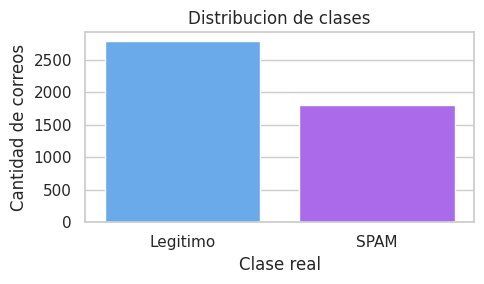

In [3]:
plt.figure(figsize=(5, 3))
sns.countplot(data=dataset, x="spam", hue="spam", palette="cool", legend=False)
plt.xticks([0, 1], ["Legitimo", "SPAM"])
plt.xlabel("Clase real")
plt.ylabel("Cantidad de correos")
plt.title("Distribucion de clases")
plt.tight_layout()
plt.show()

## 2. Separacion en variables y conjuntos

`X` contiene los atributos de entrada y `y` contiene la etiqueta que queremos predecir.

Usamos `train_test_split` para entrenar con una parte de los datos y evaluar con datos no vistos por el modelo. Esto permite estimar mejor la capacidad de generalizacion.

In [4]:
from sklearn.model_selection import train_test_split

X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (3220, 54) (3220,)
Test: (1381, 54) (1381,)


## 3. Modelos usados

### Regresion logistica

La regresion logistica aprende una combinacion lineal de los atributos y la transforma en una probabilidad mediante una funcion sigmoide. Como sus coeficientes dependen de la escala de las variables, conviene estandarizar los atributos antes de entrenar.

Para evitar fuga de informacion, la estandarizacion se coloca dentro de un `Pipeline`: el `StandardScaler` aprende media y desvio solo del entrenamiento, y luego transforma entrenamiento y test de manera consistente.

### Naive Bayes

Naive Bayes usa probabilidades condicionadas y asume independencia entre atributos dado el valor de la clase. Para este dataset elegimos `MultinomialNB`, porque las variables son frecuencias no negativas asociadas a palabras y simbolos, un caso muy cercano a conteos/frecuencias de texto. No se aplica normalizacion porque la consigna lo pide asi y porque el modelo espera entradas no negativas.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000)),
])

naive_bayes = MultinomialNB()

log_reg.fit(X_train, y_train)
naive_bayes.fit(X_train, y_train)

MultinomialNB()

## 4. Metricas

- **Matriz de confusion:** muestra verdaderos negativos, falsos positivos, falsos negativos y verdaderos positivos.
- **Precision:** de todos los correos predichos como SPAM, cuantos eran realmente SPAM.
- **Recall:** de todos los correos que eran SPAM, cuantos fueron detectados por el modelo.
- **AUC:** mide que tan bien separa el modelo las clases al variar el umbral de decision.

In [6]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)

def evaluar_modelo(nombre, modelo):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    return {
        "Modelo": nombre,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "Falsos positivos": cm[0, 1],
        "Falsos negativos": cm[1, 0],
        "Matriz": cm,
    }

resultados = [
    evaluar_modelo("Regresion Logistica", log_reg),
    evaluar_modelo("Naive Bayes", naive_bayes),
]

tabla = pd.DataFrame(resultados).drop(columns="Matriz")
tabla

,Modelo,Precision,Recall,AUC,Falsos positivos,Falsos negativos
0,Regresion Logistica,0.938318,0.870017,0.972638,33,75
1,Naive Bayes,0.782793,0.961872,0.888346,154,22


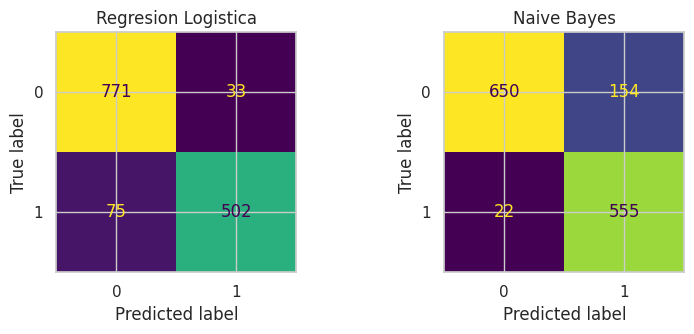

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

for ax, resultado in zip(axes, resultados):
    ConfusionMatrixDisplay(resultado["Matriz"]).plot(ax=ax, colorbar=False)
    ax.set_title(resultado["Modelo"])

plt.tight_layout()
plt.show()

## 5. Interpretacion de resultados

La regresion logistica logra mejor **precision** y mejor **AUC**. Esto significa que, cuando marca un correo como SPAM, suele equivocarse menos; ademas, ordena/separa mejor las clases si miramos distintos umbrales posibles.

Naive Bayes obtiene mejor **recall**: detecta mas correos SPAM reales. El costo es que tambien manda mas correos legitimos a la clase SPAM, es decir, aumenta los falsos positivos.

In [8]:
resumen = tabla.copy()
for col in ["Precision", "Recall", "AUC"]:
    resumen[col] = resumen[col].map(lambda x: f"{x:.4f}")
resumen

,Modelo,Precision,Recall,AUC,Falsos positivos,Falsos negativos
0,Regresion Logistica,0.9383,0.8700,0.9726,33,75
1,Naive Bayes,0.7828,0.9619,0.8883,154,22


## 6. Que error importa mas

En deteccion de SPAM hay dos errores:

- **Falso positivo:** un correo legitimo se clasifica como SPAM.
- **Falso negativo:** un correo SPAM queda como legitimo.

Mi criterio para este ejercicio es priorizar reducir falsos positivos, porque ocultar un correo legitimo puede ser mas grave para el usuario que dejar pasar algun SPAM. Con ese criterio, la regresion logistica resulta mas conveniente: comete menos falsos positivos y tiene mejor precision.

Si el contexto fuera distinto, por ejemplo una bandeja donde el usuario tolera revisar manualmente muchos correos marcados como SPAM, podria priorizarse el recall de Naive Bayes para capturar la mayor cantidad posible de SPAM.

## 7. Conclusiones

- El pipeline evita errores de preprocesamiento y mantiene junto el escalado con el modelo.
- `MultinomialNB` es una eleccion natural para frecuencias no negativas de texto.
- No alcanza con mirar una sola metrica: precision, recall y AUC cuentan partes distintas de la historia.
- Para este caso, la regresion logistica es el modelo mas equilibrado si queremos evitar marcar correos legitimos como SPAM.